In [6]:
# pip install scikit-learn matplotlib seaborn
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, r2_score, mean_absolute_error, root_mean_squared_error)
from sklearn import datasets
sns.set_theme(context='notebook', style='whitegrid')
np.random.seed(0)

In [7]:
#Classification — Iris (stratified split)
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
np.bincount(y), np.bincount(y_train), np.bincount(y_test)  # check class proportions

(array([50, 50, 50]), array([38, 37, 37]), array([12, 13, 13]))

Test accuracy: 0.921
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



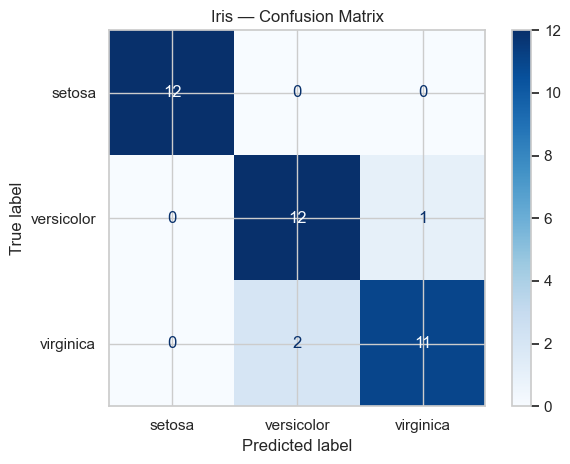

In [8]:
#Fit pipeline (StandardScaler → LogisticRegression)
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=iris.target_names))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(cmap='Blues')
plt.title("Iris — Confusion Matrix"); plt.tight_layout(); plt.show()

In [9]:
#Vary split ratio & random_state
ratios = [0.2, 0.25, 0.33]
seeds  = [0, 1, 2, 42]
scores = []
for t in ratios:
    for rs in seeds:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=t, random_state=rs, stratify=y)
        pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xtr, ytr)
        scores.append((t, rs, accuracy_score(yte, pipe.predict(Xte))))
scores  # scan accuracy stability

[(0.2, 0, 0.9666666666666667),
 (0.2, 1, 0.9666666666666667),
 (0.2, 2, 1.0),
 (0.2, 42, 0.9333333333333333),
 (0.25, 0, 0.9736842105263158),
 (0.25, 1, 0.9736842105263158),
 (0.25, 2, 1.0),
 (0.25, 42, 0.9210526315789473),
 (0.33, 0, 0.96),
 (0.33, 1, 0.98),
 (0.33, 2, 1.0),
 (0.33, 42, 0.92)]

R^2=0.453  MAE=42.79  RMSE=53.85


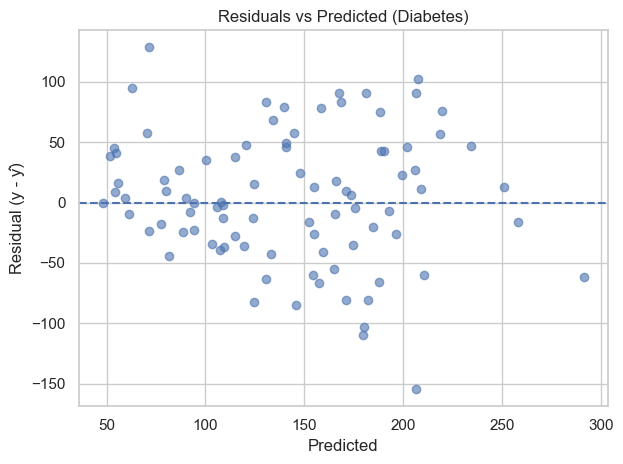

In [10]:
#Regression — Diabetes dataset
diab = datasets.load_diabetes()
Xd, yd = diab.data, diab.target

Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, random_state=42)
reg = LinearRegression().fit(Xd_train, yd_train)
yd_pred = reg.predict(Xd_test)

r2   = r2_score(yd_test, yd_pred)
mae  = mean_absolute_error(yd_test, yd_pred)
rmse = root_mean_squared_error(yd_test, yd_pred)
print(f"R^2={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}")

# Residuals
plt.figure()
plt.scatter(yd_pred, yd_test - yd_pred, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.title("Residuals vs Predicted (Diabetes)")
plt.xlabel("Predicted"); plt.ylabel("Residual (y - ŷ)"); plt.tight_layout(); plt.show()

In [11]:
#Optional: Train/Val/Test split for tuning
# Start with held-out test
X_full_tr, X_hold, y_full_tr, y_hold = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)
# Split training again to make a validation set
X_tr, X_val, y_tr, y_val = train_test_split(X_full_tr, y_full_tr, test_size=0.2, random_state=123, stratify=y_full_tr)

Cs = [0.1, 1.0, 10.0]
val_scores = []
for C in Cs:
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=C)).fit(X_tr, y_tr)
    val_scores.append((C, accuracy_score(y_val, pipe.predict(X_val))))
val_scores

best_C = max(val_scores, key=lambda t: t[1])[0]
best_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=best_C)).fit(X_full_tr, y_full_tr)
print("Chosen C:", best_C, " | Test accuracy:", round(accuracy_score(y_hold, best_pipe.predict(X_hold)), 3))

Chosen C: 1.0  | Test accuracy: 0.933


10 seeds — Test accuracy: mean = 0.945, std = 0.036


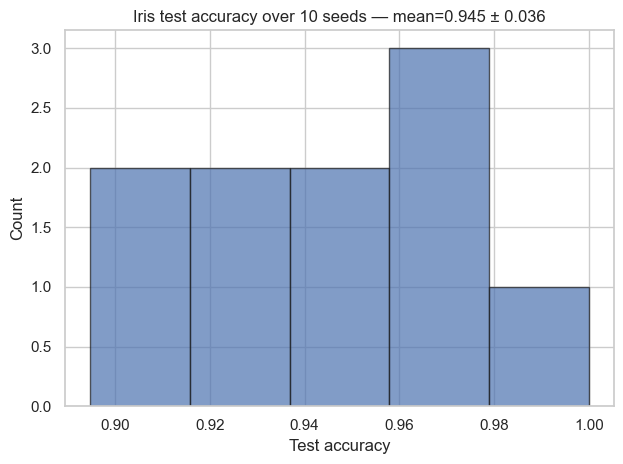

In [12]:
# Iris: run 10 random seeds, plot histogram of test accuracy, report mean ± std
seeds = list(range(10))
accs = []
for s in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=s, stratify=y)
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
    accs.append(accuracy_score(y_te, pipe.predict(X_te)))

import numpy as np
accs = np.array(accs)
mean_acc = accs.mean()
std_acc = accs.std(ddof=1)
print(f'10 seeds — Test accuracy: mean = {mean_acc:.3f}, std = {std_acc:.3f}')

plt.figure()
plt.hist(accs, bins=5, edgecolor='k', alpha=0.7)
plt.xlabel('Test accuracy')
plt.ylabel('Count')
plt.title(f'Iris test accuracy over 10 seeds — mean={mean_acc:.3f} ± {std_acc:.3f}')
plt.tight_layout(); plt.show()

test_size=0.10 -> mean acc = 0.973 ± 0.034
test_size=0.30 -> mean acc = 0.949 ± 0.036
test_size=0.40 -> mean acc = 0.957 ± 0.029


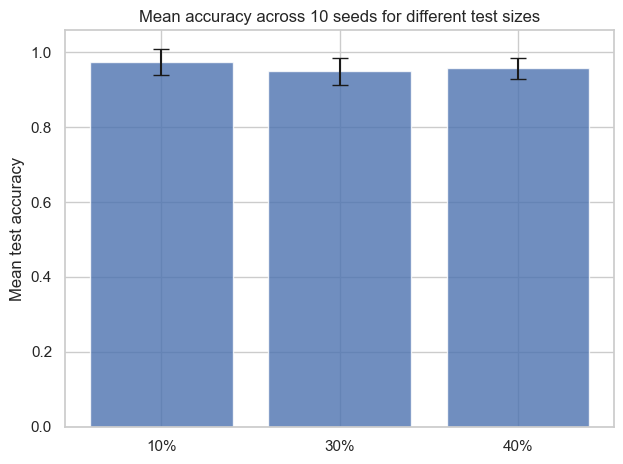

In [13]:
# Compare test sizes 0.10, 0.30, 0.40: average accuracy across 10 seeds
test_sizes = [0.10, 0.30, 0.40]
seeds = list(range(10))
results = {}
for t in test_sizes:
    accs = []
    for s in seeds:
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=t, random_state=s, stratify=y)
        pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
        accs.append(accuracy_score(y_te, pipe.predict(X_te)))
    results[t] = np.array(accs)

# Print mean ± std for each test size
for t in test_sizes:
    m = results[t].mean(); sd = results[t].std(ddof=1)
    print(f'test_size={t:.2f} -> mean acc = {m:.3f} ± {sd:.3f}')

# Bar plot with error bars
plt.figure()
means = [results[t].mean() for t in test_sizes]
stds = [results[t].std(ddof=1) for t in test_sizes]
labels = [f'{int(t*100)}%' for t in test_sizes]
plt.bar(labels, means, yerr=stds, capsize=6, color='C0', alpha=0.8)
plt.ylabel('Mean test accuracy')
plt.title('Mean accuracy across 10 seeds for different test sizes')
plt.tight_layout(); plt.show()

In [14]:
# Diabetes: compare unscaled LinearRegression vs StandardScaler + LinearRegression
# Use the same split as earlier (test_size=0.2, random_state=42)
from sklearn.pipeline import make_pipeline

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(Xd, yd, test_size=0.2, random_state=42)

# Unscaled linear regression
reg_un = LinearRegression().fit(X_d_train, y_d_train)
y_un = reg_un.predict(X_d_test)
r2_un = r2_score(y_d_test, y_un)
mae_un = mean_absolute_error(y_d_test, y_un)
rmse_un = root_mean_squared_error(y_d_test, y_un)

# Scaled (StandardScaler → LinearRegression)
pipe_scaled = make_pipeline(StandardScaler(), LinearRegression()).fit(X_d_train, y_d_train)
y_sc = pipe_scaled.predict(X_d_test)
r2_sc = r2_score(y_d_test, y_sc)
mae_sc = mean_absolute_error(y_d_test, y_sc)
rmse_sc = root_mean_squared_error(y_d_test, y_sc)

print('Diabetes regression (test_size=0.2, random_state=42)')
print('Unscaled  ->', f'R2={r2_un:.3f}', f'MAE={mae_un:.2f}', f'RMSE={rmse_un:.2f}')
print('Scaled    ->', f'R2={r2_sc:.3f}', f'MAE={mae_sc:.2f}', f'RMSE={rmse_sc:.2f}')

print('Note: Ordinary least-squares LinearRegression is invariant to linear rescaling of features in terms of achievable predictions (coefficients change accordingly).')
print('Scaling may still affect numerical stability and is required for regularized models (e.g., Ridge, Lasso) or distance-based methods; interpret coefficient magnitudes with scaled features accordingly.')

Diabetes regression (test_size=0.2, random_state=42)
Unscaled  -> R2=0.453 MAE=42.79 RMSE=53.85
Scaled    -> R2=0.453 MAE=42.79 RMSE=53.85
Note: Ordinary least-squares LinearRegression is invariant to linear rescaling of features in terms of achievable predictions (coefficients change accordingly).
Scaling may still affect numerical stability and is required for regularized models (e.g., Ridge, Lasso) or distance-based methods; interpret coefficient magnitudes with scaled features accordingly.


In [15]:
# Diabetes: train/val/test split; sweep PolynomialFeatures degrees 1-4, choose on validation, report test R²
from sklearn.preprocessing import PolynomialFeatures

# Train (50%), Val (25%), Test (25%)
X_tr, X_temp, y_tr, y_temp = train_test_split(Xd, yd, test_size=0.5, random_state=123)
X_val, X_te, y_val, y_te = train_test_split(X_temp, y_temp, test_size=0.5, random_state=123)

print(f"Splits: train={len(X_tr)}, val={len(X_val)}, test={len(X_te)}")

# Sweep degrees 1-4 on validation set
degrees = [1, 2, 3, 4]
val_r2s = []
for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_poly = poly.fit_transform(X_tr)
    X_val_poly = poly.transform(X_val)
    
    reg = LinearRegression().fit(X_tr_poly, y_tr)
    y_val_pred = reg.predict(X_val_poly)
    val_r2 = r2_score(y_val, y_val_pred)
    val_r2s.append((deg, val_r2))
    print(f"degree={deg}: validation R² = {val_r2:.3f}")

# Choose best degree
best_deg = max(val_r2s, key=lambda t: t[1])[0]
print(f"\nChosen degree: {best_deg}")

# Evaluate on test set with chosen degree
poly_best = PolynomialFeatures(degree=best_deg, include_bias=False)
X_tr_poly = poly_best.fit_transform(X_tr)
X_te_poly = poly_best.transform(X_te)
reg_best = LinearRegression().fit(X_tr_poly, y_tr)
y_te_pred = reg_best.predict(X_te_poly)
test_r2 = r2_score(y_te, y_te_pred)

print(f"Test R² (degree={best_deg}): {test_r2:.3f}")

Splits: train=221, val=110, test=111
degree=1: validation R² = 0.439
degree=2: validation R² = 0.328
degree=3: validation R² = -79.541
degree=4: validation R² = -27.061

Chosen degree: 1
Test R² (degree=1): 0.445
